🧩 Paso 1: Cargar y explorar

1.1 Carga de datos y vista rápida

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
plans = pd.read_csv("/datasets/plans.csv")

In [5]:
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [6]:
users = pd.read_csv("/datasets/users_latam.csv")

In [7]:
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [8]:
usage = pd.read_csv("/datasets/usage.csv")

In [9]:
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


In [10]:
print(plans.head())

  plan_name  messages_included  gb_per_month  minutes_included  \
0    Basico                100             5               100   
1   Premium                500            20               600   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute  
0               12         1.2             0.08            0.10  
1               25         1.0             0.05            0.07  


In [11]:
print(users.head())

   user_id first_name last_name  age      city                       reg_date  \
0    10000     Carlos    Garcia   38  Medellín  2022-01-01 00:00:00.000000000   
1    10001      Mateo    Torres   53         ?  2022-01-01 06:34:17.914478619   
2    10002      Sofia   Ramirez   57      CDMX  2022-01-01 13:08:35.828957239   
3    10003      Mateo   Ramirez   69    Bogotá  2022-01-01 19:42:53.743435858   
4    10004      Mateo    Torres   63       GDL  2022-01-02 02:17:11.657914478   

      plan churn_date  
0   Basico        NaN  
1   Basico        NaN  
2   Basico        NaN  
3  Premium        NaN  
4   Basico        NaN  


In [12]:
print(usage.head())

   id  user_id  type                           date  duration  length
0   1    10332  call  2024-01-01 00:00:00.000000000      0.09     NaN
1   2    11458  text  2024-01-01 00:06:30.969774244       NaN    39.0
2   3    11777  text  2024-01-01 00:13:01.939548488       NaN    36.0
3   4    10682  call  2024-01-01 00:19:32.909322733      1.53     NaN
4   5    12742  call  2024-01-01 00:26:03.879096977      4.84     NaN


In [13]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [14]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [15]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


🧩Paso 2: Identificación de problemas de calidad de datos

2.1 Revisión de valores nulos

In [16]:
print('Nulos en users:')
print(users.isna().sum())
print()

print('Proporción de nulos en users:')
print(users.isna().mean())
print()

Nulos en users:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de nulos en users:
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64



In [17]:
print('Nulos en usage:')
print(usage.isna().sum())
print()

print('Proporción de nulos en usage:')
print(usage.isna().mean())

Nulos en usage:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de nulos en usage:
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


2.2 Detección de valores inválidos y sentinels

In [18]:
print(users[['user_id', 'age']].describe())

            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


In [19]:
print(usage[['id', 'user_id', 'duration', 'length']].describe())

                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


In [20]:
columnas_user = ['city', 'plan']

for col in columnas_user:
    print(f'\nColumna: {col}')
    print(users[col].value_counts(dropna=False))
    print('Valores únicos:', users[col].nunique(dropna=True))


Columna: city
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64
Valores únicos: 7

Columna: plan
Basico     2595
Premium    1405
Name: plan, dtype: int64
Valores únicos: 2


In [21]:
# explorar columna categórica de usage
print(usage['type'].value_counts(dropna=False))
print('Valores únicos:', usage['type'].unique())

text    22092
call    17908
Name: type, dtype: int64
Valores únicos: ['call' 'text']


2.3 Revisión y estandarización de fechas

In [22]:
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [23]:
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [24]:
print(users['reg_date'].dt.year.value_counts().sort_index())

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


In [25]:
print(usage['date'].dt.year.value_counts(dropna=False).sort_index())

2024.0    39950
NaN          50
Name: date, dtype: int64


🧩Paso 3: Limpieza básica de datos

3.1 Corregir sentinels y fechas imposibles

In [26]:
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [27]:
users['city'] = users['city'].replace('?', pd.NA)

users['city'].value_counts(dropna=False)
users['city'].isna().sum()

565

In [28]:
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

users['reg_date'].dt.year.value_counts(dropna=False).sort_index()
users['reg_date'].isna().sum()

40

3.2 Corregir sentinels y fechas imposibles

In [29]:
print(pd.crosstab(usage['type'], usage['duration'].isna()))
print()
print(pd.crosstab(usage['type'], usage['duration'].isna(), normalize='index'))

duration  False  True 
type                  
call      17908      0
text         16  22076

duration     False     True 
type                        
call      1.000000  0.000000
text      0.000724  0.999276


In [30]:
print(pd.crosstab(usage['type'], usage['length'].isna()))
print()
print(pd.crosstab(usage['type'], usage['length'].isna(), normalize='index'))

length  False  True 
type                
call       12  17896
text    22092      0

length    False    True 
type                    
call    0.00067  0.99933
text    1.00000  0.00000


🧩Paso 4: Summary statistics de uso por usuario

 4.1 Agrupación por comportamiento de uso

In [31]:
usage["is_text"] = (usage["type"] == "text").astype(int)
usage["is_call"] = (usage["type"] == "call").astype(int)

usage["call_minutes"] = usage["duration"].where(usage["type"] == "call", 0).fillna(0)

In [32]:
usage_agg = usage.groupby("user_id")[["is_text", "is_call", "call_minutes"]].sum().reset_index()

usage_agg.head(3)

,user_id,is_text,is_call,call_minutes
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [33]:
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "call_minutes": "cant_minutos_llamada"
})

usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [34]:
user_profile = users.merge(usage_agg, on="user_id", how="left")

user_profile[["cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]] = (
    user_profile[["cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]].fillna(0)
)

user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


4.2 Resumen estadístico por usuario durante el 2024

In [35]:
user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000,4000.000000
mean,48.136000,5.523000,4.477000,22.831225
std,17.689919,2.359738,2.145139,16.592068
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.087500
50%,48.000000,5.000000,4.000000,19.735000
75%,63.000000,7.000000,6.000000,31.182500
max,79.000000,17.000000,15.000000,155.690000


In [36]:
(user_profile['plan'].value_counts(normalize=True) * 100).round(2)

Basico     64.88
Premium    35.12
Name: plan, dtype: float64

🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers

5.1 Visualización de Distribuciones

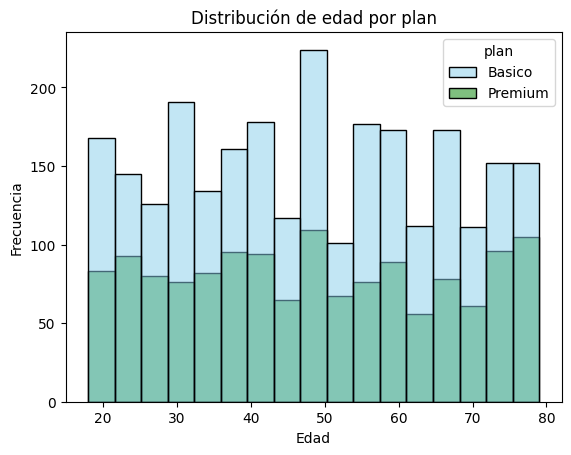

In [37]:
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de edad por plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

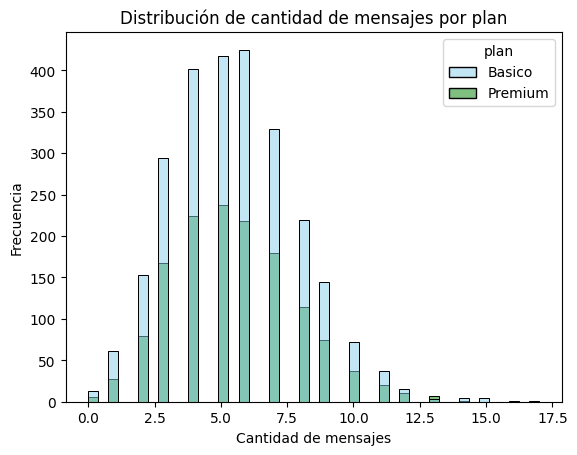

In [38]:
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de cantidad de mensajes por plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.show()

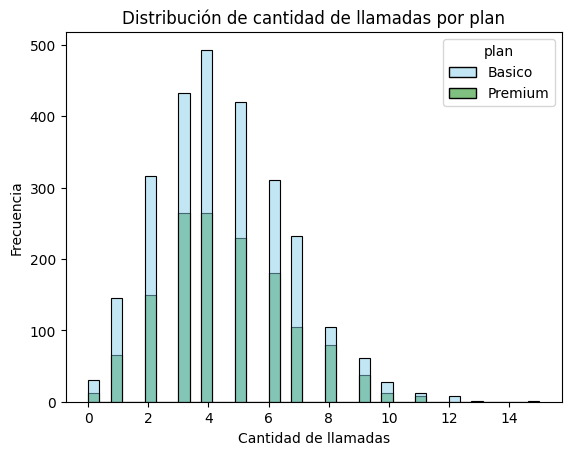

In [39]:
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de cantidad de llamadas por plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()

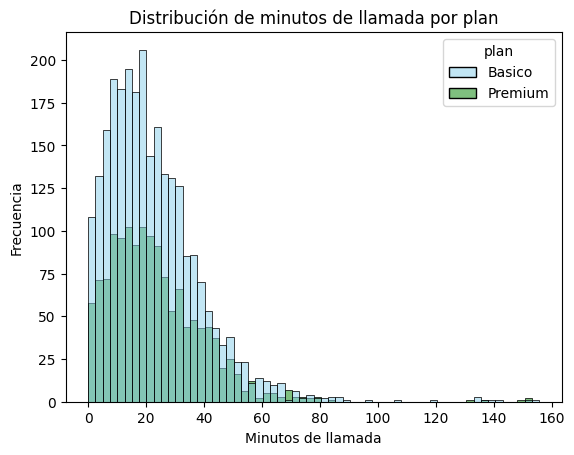

In [40]:
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de minutos de llamada por plan')
plt.xlabel('Minutos de llamada')
plt.ylabel('Frecuencia')
plt.show()

5.2 Identificación de Outliers

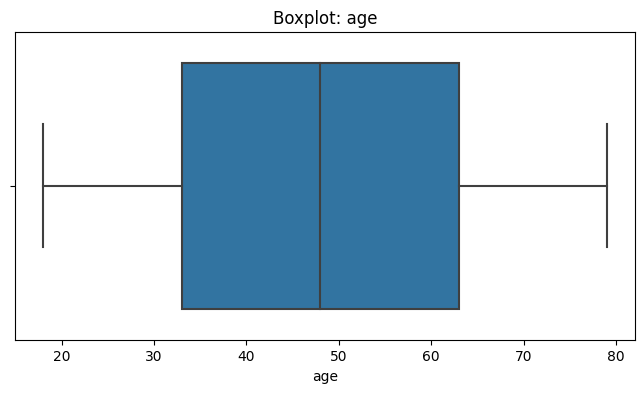

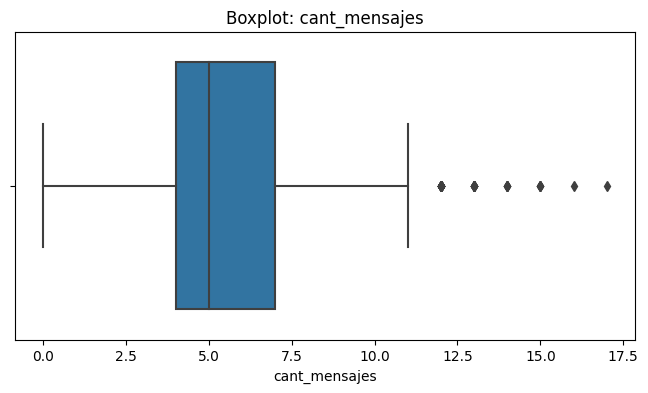

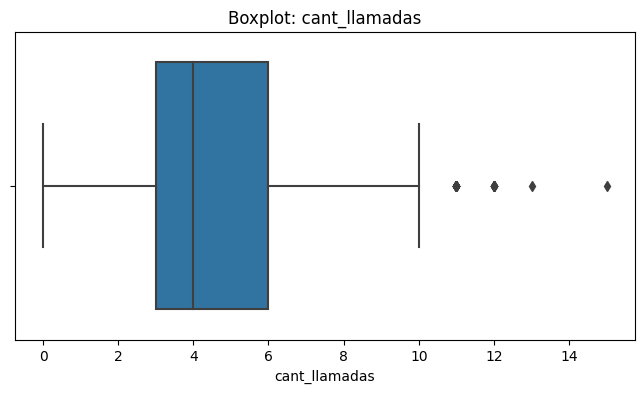

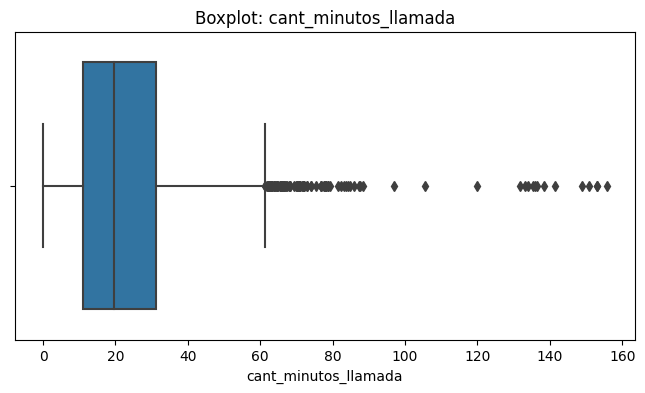

In [41]:
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

In [42]:
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    q1 = user_profile[col].quantile(0.25)
    q3 = user_profile[col].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    
    print(f'Columna: {col}')
    print(f'Q1: {q1}')
    print(f'Q3: {q3}')
    print(f'IQR: {iqr}')
    print(f'Límite inferior: {limite_inferior}')
    print(f'Límite superior: {limite_superior}')
    print()

Columna: cant_mensajes
Q1: 4.0
Q3: 7.0
IQR: 3.0
Límite inferior: -0.5
Límite superior: 11.5

Columna: cant_llamadas
Q1: 3.0
Q3: 6.0
IQR: 3.0
Límite inferior: -1.5
Límite superior: 10.5

Columna: cant_minutos_llamada
Q1: 11.0875
Q3: 31.182499999999997
IQR: 20.095
Límite inferior: -19.055
Límite superior: 61.324999999999996



In [43]:
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000
mean,5.523000,4.477000,22.831225
std,2.359738,2.145139,16.592068
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.087500
50%,5.000000,4.000000,19.735000
75%,7.000000,6.000000,31.182500
max,17.000000,15.000000,155.690000


🧩Paso 6: Segmentación de Clientes

6.1 Segmentación de Clientes Por Uso

In [44]:
user_profile['grupo_uso'] = 'Alto uso'

user_profile.loc[
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    'grupo_uso'
] = 'Bajo uso'

user_profile.loc[
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10) &
    ~((user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5)),
    'grupo_uso'
] = 'Uso medio'

In [45]:
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


6.2 Segmentación de Clientes Por Edad

In [47]:
cond_joven = user_profile['age'] < 30
cond_adulto = user_profile['age'] < 60

user_profile['grupo_edad'] = 'Adulto Mayor'
user_profile.loc[cond_adulto, 'grupo_edad'] = 'Adulto'
user_profile.loc[cond_joven, 'grupo_edad'] = 'Joven'

In [48]:
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


 6.3 Visualización de la Segmentación de Clientes

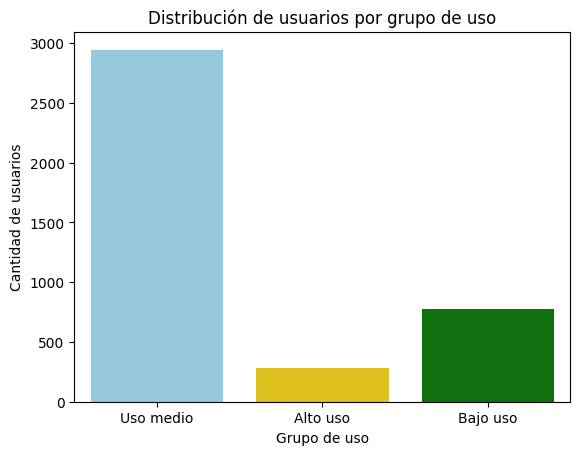

In [49]:
sns.countplot(data=user_profile, x='grupo_uso', palette=['skyblue', 'gold', 'green'])

plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')

plt.show()

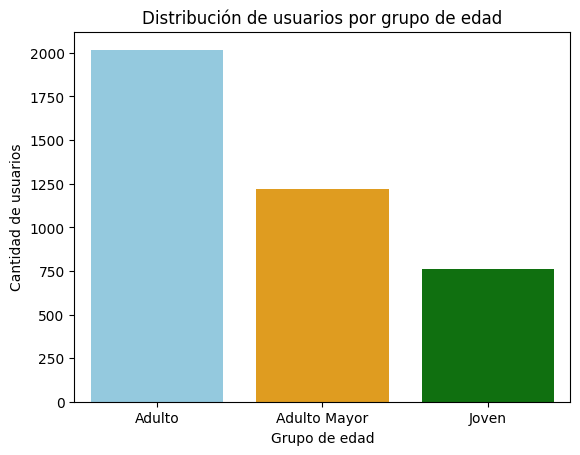

In [50]:
sns.countplot(data=user_profile, x='grupo_edad', palette=['skyblue', 'orange', 'green'])

plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')

plt.show()